
Personal Budget Analysis — Planned / Actual Spend

Business problem: I want to know if im actually sticking to my budget  and if im not, which categories are the real problem. im comparing what i planned to spend 'budget 'data against what I actually spent 'personal transaction', by category and checking the trend over time

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
transactions = pd.read_csv('personal_transactions.csv')   # load data
budget = pd.read_csv('Budget.csv')

transactions

,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card
...,...,...,...,...,...,...
801,09/27/2019,Biweekly Paycheck,2250.00,credit,Paycheck,Checking
802,09/28/2019,BP,33.46,debit,Gas & Fuel,Platinum Card
803,09/28/2019,Sheetz,4.27,debit,Gas & Fuel,Platinum Card
804,09/30/2019,Starbucks,1.75,debit,Coffee Shops,Platinum Card


In [5]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              806 non-null    object 
 1   Description       806 non-null    object 
 2   Amount            806 non-null    float64
 3   Transaction Type  806 non-null    object 
 4   Category          806 non-null    object 
 5   Account Name      806 non-null    object 
dtypes: float64(1), object(5)
memory usage: 37.9+ KB


In [6]:
budget

,Category,Budget
0,Alcohol & Bars,50
1,Auto Insurance,75
2,Coffee Shops,15
3,Electronics & Software,0
4,Entertainment,25
5,Fast Food,15
6,Gas & Fuel,75
7,Groceries,150
8,Haircut,30
9,Home Improvement,250




i need to drop sm categories

1st - paycheck is income not spending and u see it is credit trans.type so its income

2nd -credit card payment - it is not real spending bcs appears as debit and credit so maybe it is internal transfer betwen my cards

and converting DATE  to an actual date and adding a MONTH  column so i can do   chart later

In [7]:
transactions['Date'] = pd.to_datetime(transactions['Date'])
transactions['Month'] = transactions['Date'].dt.to_period('M')

# drop categories
spend = transactions[~transactions['Category'].isin(['Paycheck', 'Credit Card Payment'])].copy()



spend by category — Pie chart

 there  is tooo much category
 for pie chart so im keeping the top 8 and marking   rest as  "Other"

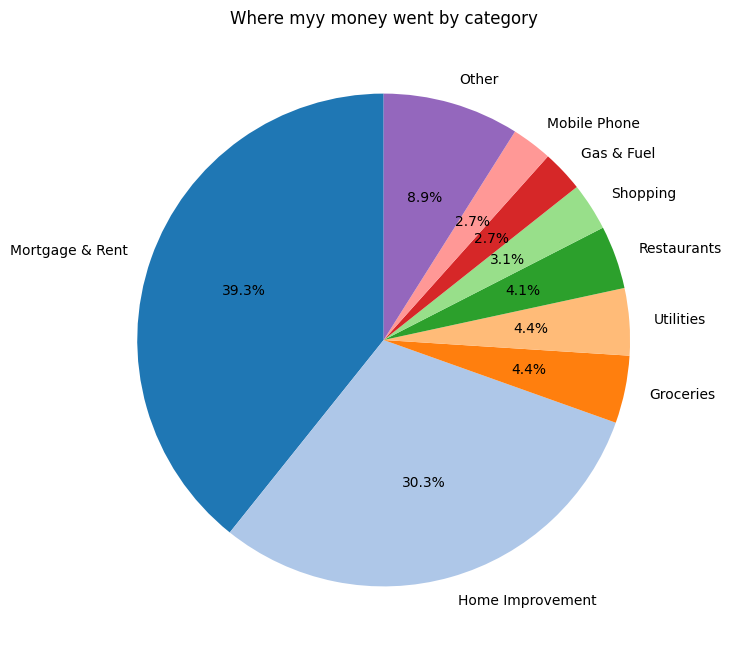

In [8]:
cat_totals = spend.groupby('Category')['Amount'].sum().sort_values(ascending=False)

top8 = cat_totals[:8]
other = pd.Series({'Other': cat_totals[8:].sum()})
pie_data = pd.concat([top8, other])

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.tab20.colors)
plt.title('Where myy money went by category')
plt.show()

monthly spend trend — Line chart

Adding everything up by month to see  spending state

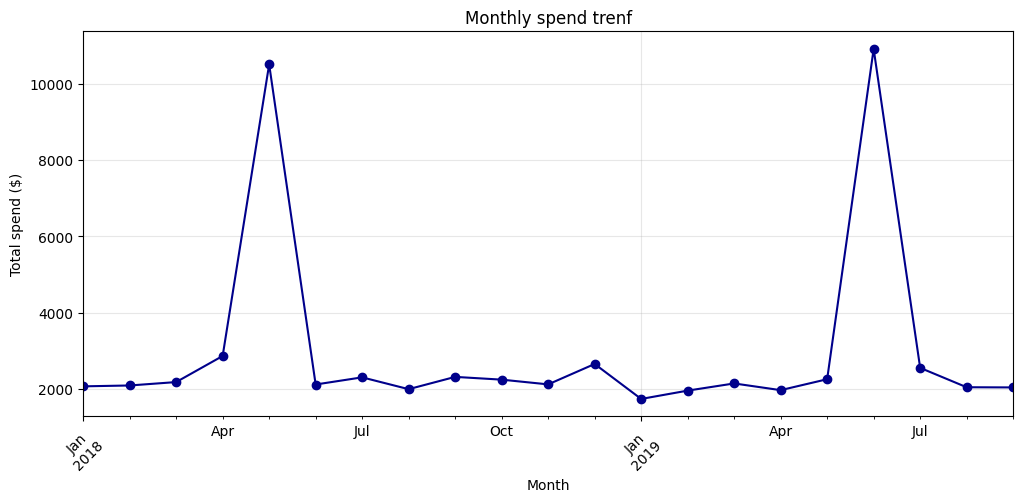

In [9]:
monthly_totals = spend.groupby('Month')['Amount'].sum()

plt.figure(figsize=(12, 5))
monthly_totals.plot(kind='line', marker='o', color='darkblue')
plt.title('Monthly spend trenf')
plt.ylabel('Total spend ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

Thereis 2 huge parts May 2018 and June 2019  . i wanna know thay are bad spendings or not

In [14]:
# let's check what is these spendings
may_2018 = spend[spend['Month'] == '2018-05'].groupby('Category')['Amount'].sum()
june_2019 = spend[spend['Month'] == '2019-06'].groupby('Category')['Amount'].sum()

print(may_2018.sort_values(ascending=False).head(3))
print(june_2019.sort_values(ascending=False).head(3))

Category
Home Improvement    8022.37
Mortgage & Rent     1247.44
Groceries            289.21
Name: Amount, dtype: float64
Category
Home Improvement    9200.0
Mortgage & Rent     1100.0
Utilities            125.0
Name: Amount, dtype: float64


Yep these months arent really bad overspending months

 Budget / Actual  by Category

Budget data is a monthly budget per category but my transaction data covers 21 months so i need to turn my totals into a monthly average before I can compare them fairly

In [15]:
# i have 21 months of data  so i divide by 21 to get monthly average
monthly_avg = cat_totals / 21

# add monthly average column to budget table
budget['Actual'] = budget['Category'].map(monthly_avg)

# to  know how much over or under
budget['Difference'] = budget['Actual'] - budget['Budget']

budget

,Category,Budget,Actual,Difference
0,Alcohol & Bars,50,25.672857,-24.327143
1,Auto Insurance,75,64.285714,-10.714286
2,Coffee Shops,15,5.501905,-9.498095
3,Electronics & Software,0,34.238095,34.238095
4,Entertainment,25,0.458095,-24.541905
5,Fast Food,15,15.744286,0.744286
6,Gas & Fuel,75,81.674762,6.674762
7,Groceries,150,133.105238,-16.894762
8,Haircut,30,18.000000,-12.000000
9,Home Improvement,250,909.184286,659.184286




 few things to note

electronics software and Movies- DVDs have 0 budget so the difference is just the raw overspend — never planned for these

 almost everything else  is actually under budget

Home Improvement looks like the big problem at $659 over per month — but that number is very misleading bcs of 2 months had 1 giant payment so actually it is not 659 for per month

In [17]:
#Highest-spend categories — ranked table
ranked = cat_totals.reset_index()
ranked.columns = ['Category', 'Total_Spend']
ranked

,Category,Total_Spend
0,Mortgage & Rent,24754.50
1,Home Improvement,19092.87
2,Groceries,2795.21
3,Utilities,2776.00
4,Restaurants,2613.02
5,Shopping,1973.24
6,Gas & Fuel,1715.17
7,Mobile Phone,1680.40
8,Internet,1570.88
9,Auto Insurance,1350.00


 outcome

Home I=improvement looks 264% over budge  but it s not really  overspending problem — two big contractor payments 17,200 out of 19,093 total are making it look  worse than it is. Take those out and the real monthly home spending is only around $90  which is actualky under the  budget. other spendigs  like coffee, eating out, groceries and entertainment are all under budget too, The only real action here is to track renovation costss separately from regular home maintenance

This analysis help budget owner decide whether they re actually overspending or just need to split their budget categories better